In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("phase 2 data.csv")
df

,Index,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,...,College 1 year to 3 years (Some college or technical school),College 4 years or more (College graduate),"Earns Less than $10,000 Annually","Earns $10,000-$14,999 Annually","Earns $15,000-$19,999 Annually","Earns $20,000-$24,999 Annually","Earns $25,000-$34,999 Annually","Earns $35,000-$49,999 Annually","Earns $50,000-$74,999 Annually","Earns More than $75,000 Annually"
0,0,0.0,1.0,1.0,1.0,1.316755,1.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
1,1,0.0,0.0,0.0,0.0,-0.312639,1.0,0.0,0.0,1.0,...,0,1,1,0,0,0,0,0,0,0
2,2,0.0,1.0,1.0,1.0,0.140916,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,3,0.0,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,4,0.0,1.0,1.0,1.0,-0.486739,0.0,0.0,0.0,1.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,253675,0.0,1.0,1.0,1.0,1.633059,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,1,0
253676,253676,2.0,1.0,1.0,1.0,-1.893247,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
253677,253677,0.0,0.0,0.0,1.0,0.140916,0.0,0.0,0.0,1.0,...,1,0,0,1,0,0,0,0,0,0
253678,253678,0.0,1.0,0.0,1.0,-0.674597,0.0,0.0,0.0,0.0,...,1,0,1,0,0,0,0,0,0,0


In [3]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

X = df.drop(columns=["Diabetes_012","Index"])
X

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,College 1 year to 3 years (Some college or technical school),College 4 years or more (College graduate),"Earns Less than $10,000 Annually","Earns $10,000-$14,999 Annually","Earns $15,000-$19,999 Annually","Earns $20,000-$24,999 Annually","Earns $25,000-$34,999 Annually","Earns $35,000-$49,999 Annually","Earns $50,000-$74,999 Annually","Earns More than $75,000 Annually"
0,1.0,1.0,1.0,1.316755,1.0,0.0,0.0,0.0,0.0,1.0,...,0,0,0,0,1,0,0,0,0,0
1,0.0,0.0,0.0,-0.312639,1.0,0.0,0.0,1.0,0.0,0.0,...,0,1,1,0,0,0,0,0,0,0
2,1.0,1.0,1.0,0.140916,0.0,0.0,0.0,0.0,1.0,0.0,...,0,0,0,0,0,0,0,0,0,1
3,1.0,0.0,1.0,0.000000,0.0,0.0,0.0,1.0,1.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,1.0,1.0,1.0,-0.486739,0.0,0.0,0.0,1.0,1.0,1.0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,1.0,1.0,1.0,1.633059,0.0,0.0,0.0,0.0,1.0,1.0,...,0,1,0,0,0,0,0,0,1,0
253676,1.0,1.0,1.0,-1.893247,0.0,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
253677,0.0,0.0,1.0,0.140916,0.0,0.0,0.0,1.0,1.0,0.0,...,1,0,0,1,0,0,0,0,0,0
253678,1.0,0.0,1.0,-0.674597,0.0,0.0,0.0,0.0,1.0,1.0,...,1,0,1,0,0,0,0,0,0,0


In [4]:
y= df["Diabetes_012"]
y

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
253675    0.0
253676    2.0
253677    0.0
253678    0.0
253679    2.0
Name: Diabetes_012, Length: 253680, dtype: float64

In [5]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
kf

KFold(n_splits=10, random_state=42, shuffle=True)

In [6]:
nbclf = GaussianNB()
nbclf

GaussianNB()

In [7]:
Precision = []
Recall = []
F1 = []
Accuracy = []
AUC = []

for train_indexes, test_indexes in kf.split(X):
    X_train, X_test = X.iloc[train_indexes], X.iloc[test_indexes]
    y_train, y_test = y.iloc[train_indexes], y.iloc[test_indexes]
    nbclf.fit(X_train, y_train)
    y_pred = nbclf.predict(X_test)
    y_pred_prob = nbclf.predict_proba(X_test)
    Precision.append(precision_score(y_test, y_pred, average=None))
    Recall.append(recall_score(y_test, y_pred, average=None))
    F1.append(f1_score(y_test, y_pred, average=None))
    Accuracy.append(accuracy_score(y_test, y_pred))
    AUC.append(roc_auc_score(y_test, y_pred_prob, multi_class='ovr'))

Precision,Recall,F1,Accuracy,AUC

([array([0.93708968, 0.03403566, 0.28602957]),
  array([0.93691233, 0.0260521 , 0.28666886]),
  array([0.93397472, 0.03824092, 0.28371729]),
  array([0.93511257, 0.03269231, 0.28729526]),
  array([0.93510899, 0.02646503, 0.2941704 ]),
  array([0.93314549, 0.02862986, 0.28651625]),
  array([0.93622287, 0.03846154, 0.28585613]),
  array([0.9359007 , 0.03435115, 0.28793519]),
  array([0.93374108, 0.03525046, 0.27942626]),
  array([0.9332911 , 0.03377111, 0.28530387])],
 [array([0.68697724, 0.04439746, 0.74184316]),
  array([0.68930541, 0.02760085, 0.74707394]),
  array([0.69455226, 0.04158004, 0.72444318]),
  array([0.69128992, 0.03863636, 0.73354055]),
  array([0.69681225, 0.03153153, 0.73687167]),
  array([0.6839388 , 0.03010753, 0.73783709]),
  array([0.69061886, 0.04393305, 0.73441043]),
  array([0.68853611, 0.04026846, 0.73731427]),
  array([0.68492382, 0.04175824, 0.72603129]),
  array([0.6899911 , 0.03773585, 0.72937853])],
 [array([0.79277433, 0.03853211, 0.41287034]),
  array([0.

In [8]:
Precision = np.array(Precision)
Recall = np.array(Recall)
F1 = np.array(F1)
Accuracy = np.array(Accuracy)
AUC = np.array(AUC)

In [9]:
Diabetes_0_Precision = Precision[:, 0].mean()
Diabetes_1_Precision = Precision[:, 1].mean()
Diabetes_2_Precision = Precision[:, 2].mean()
Diabetes_0_Recall = Recall[:, 0].mean()
Diabetes_1_Recall = Recall[:, 1].mean()
Diabetes_2_Recall = Recall[:, 2].mean()
Diabetes_0_F1 = F1[:, 0].mean()
Diabetes_1_F1 = F1[:, 1].mean()
Diabetes_2_F1 = F1[:, 2].mean()
Diabetes_Accuracy = Accuracy.mean()
Diabetes_AUC = AUC.mean()
Diabetes_0_Precision, Diabetes_1_Precision, Diabetes_2_Precision, Diabetes_0_Recall, Diabetes_1_Recall, Diabetes_2_Recall, Diabetes_0_F1, Diabetes_1_F1, Diabetes_2_F1, Diabetes_Accuracy, Diabetes_AUC

(0.9350499532283958,
 0.03279501255542369,
 0.28629190803497506,
 0.6896945757808186,
 0.03775493774726614,
 0.7348744097616654,
 0.793840618976487,
 0.035068436699956976,
 0.4120456732389971,
 0.6840901923683381,
 0.7366922565990193)

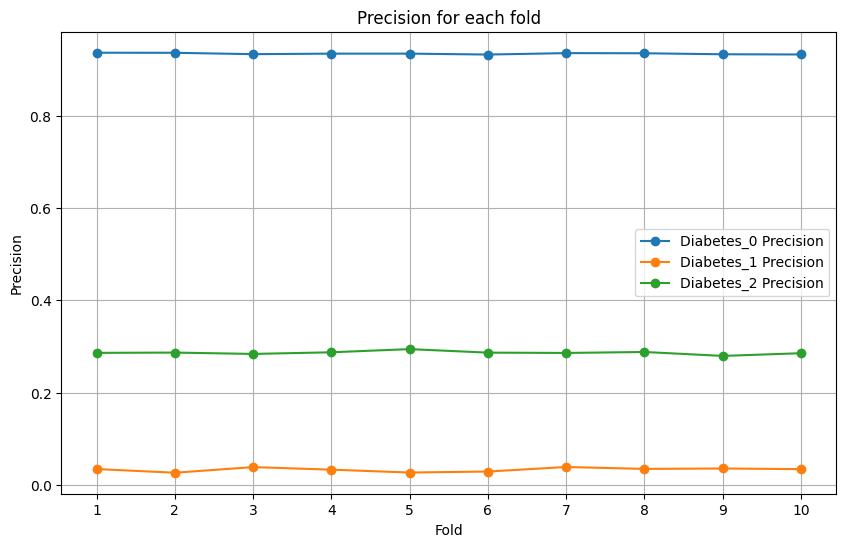

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), Precision[:, 0], marker='o', label='Diabetes_0 Precision')
plt.plot(range(1, 11), Precision[:, 1], marker='o', label='Diabetes_1 Precision')
plt.plot(range(1, 11), Precision[:, 2], marker='o', label='Diabetes_2 Precision')
plt.title('Precision for each fold')
plt.xlabel('Fold')
plt.ylabel('Precision')
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show() 

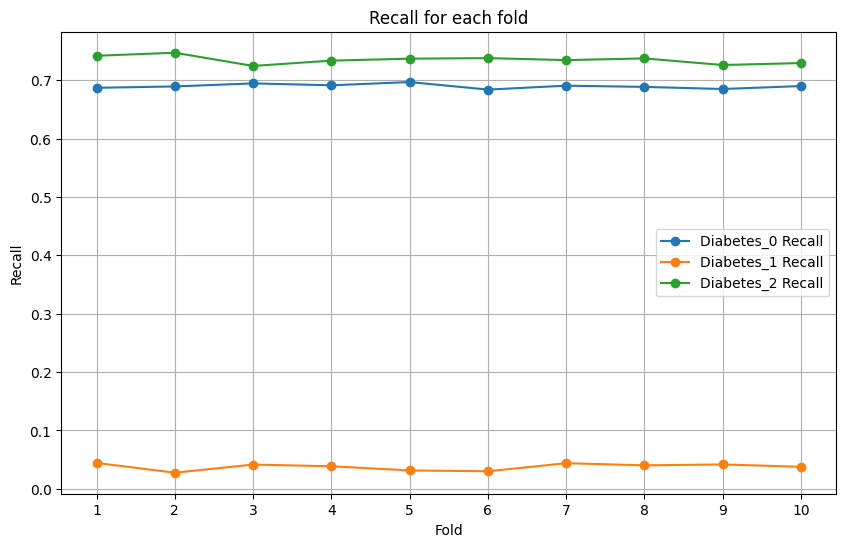

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,11), Recall[:, 0], marker='o', label='Diabetes_0 Recall')
plt.plot(range(1,11), Recall[:, 1], marker='o', label="Diabetes_1 Recall")
plt.plot(range(1,11), Recall[:, 2], marker='o', label="Diabetes_2 Recall")
plt.title("Recall for each fold")
plt.xlabel("Fold")
plt.ylabel("Recall")
plt.xticks(range(1,11))
plt.legend()
plt.grid()
plt.show()

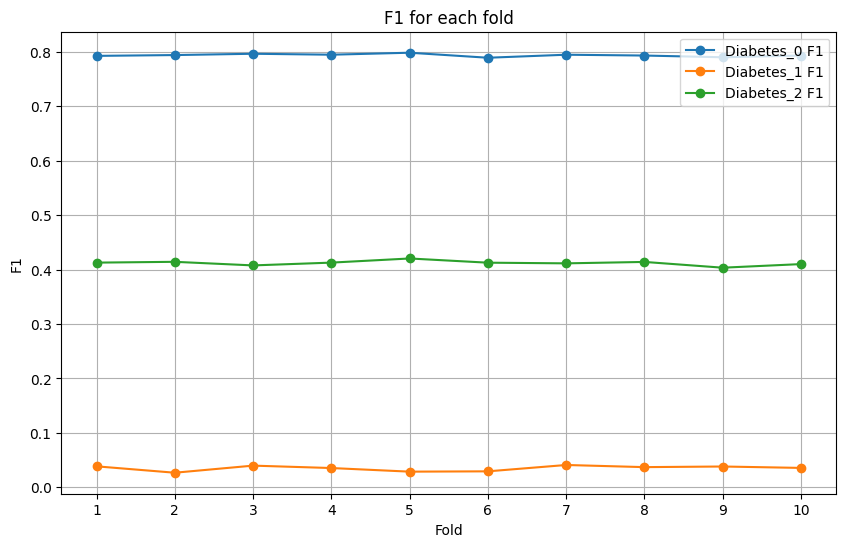

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(range(1,11), F1[:, 0], marker='o', label='Diabetes_0 F1')
plt.plot(range(1,11), F1[:, 1], marker='o', label='Diabetes_1 F1')
plt.plot(range(1,11), F1[:, 2], marker='o', label='Diabetes_2 F1')
plt.title("F1 for each fold")
plt.xlabel("Fold")
plt.ylabel("F1")
plt.xticks(range(1,11))
plt.legend()
plt.grid()
plt.show()

In [ ]:
Diabetes_Dict = {
    "Diabetes_0_Precision": Diabetes_0_Precision,
    "Diabetes_1_Precision": Diabetes_1_Precision,
    "Diabetes_2_Precision": Diabetes_2_Precision,
    "Diabetes_0_Recall": Diabetes_0_Recall,
    "Diabetes_1_Recall": Diabetes_1_Recall,
    "Diabetes_2_Recall": Diabetes_2_Recall,
    "Diabetes_0_F1": Diabetes_0_F1,
    "Diabetes_1_F1": Diabetes_1_F1,
    "Diabetes_2_F1": Diabetes_2_F1,
    "Diabetes_Accuracy": Diabetes_Accuracy,
    "Diabetes_AUC": Diabetes_AUC
}

Diabetes_Frame = pd.DataFrame(Diabetes_Dict, index=[0])
Diabetes_Frame.to_csv("Diabetes_Results_Naive.csv", index=False)
Diabetes_Frame

,Diabetes_0_Precision,Diabetes_1_Precision,Diabetes_2_Precision,Diabetes_0_Recall,Diabetes_1_Recall,Diabetes_2_Recall,Diabetes_0_F1,Diabetes_1_F1,Diabetes_2_F1,Diabetes_Accuracy,Diabetes_AUC
0,0.93505,0.032795,0.286292,0.689695,0.037755,0.734874,0.793841,0.035068,0.412046,0.68409,0.736692
